# Computer Exercise 3.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.1 Bisection Method — *Failure Modes*
> **풀이 일자**: Day 11
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Investigate the failure modes of the bisection method by constructing examples in which:
> (a) the function has the **same sign at both endpoints**, so the method cannot start;
> (b) the function has a **double (even-multiplicity) root** at which the sign does *not* change,
>     so the bracketing condition is never satisfied;
> (c) the function is **discontinuous** inside $[a, b]$ so that the sign change does not correspond
>     to an actual root (the method converges to a *pole* or a jump discontinuity).
> For each case, attempt to run bisection, record what happens, and explain *why* the method fails
> in terms of its underlying assumptions.

### 한국어 풀이용 정리
이분법이 *반드시 가정* 하는 두 조건 — **연속성** 과 **부호 변화** — 가 깨질 때
무엇이 일어나는지 셋으로 나눠서 본다:

1. **부호가 같은 경계** : 알고리즘이 *시작도 못 함*.
2. **다중근 (짝수 중복도)** : $r$ 에서 부호가 바뀌지 않으므로 bracket 을 만들 수 없음.
3. **불연속점** : 알고리즘은 *수렴* 하지만 *근이 아닌* 점(pole, jump)으로 수렴.

이 실패 모드들이 *언제* 일어나고, *어떻게* 감지하며, *무엇으로 보완* 할지 정리한다.


## 2. 수학적 배경

### 2.1 이분법이 정확히 요구하는 것

이분법의 수렴 정리는 다음 *두 가지* 를 가정한다:

(A1) $f$ 는 $[a, b]$ 에서 **연속**.
(A2) $f(a)\,f(b) < 0$ — **부호 변화**.

이 두 가지가 있으면 **IVT** 에 의해 $\exists r \in (a,b)$ s.t. $f(r) = 0$,
그리고 매 반복마다 새 구간이 여전히 (A1), (A2) 를 만족하므로 귀납적으로 수렴.

### 2.2 (A2) 위반 — 같은 부호 경계
$f(a)\,f(b) > 0$ 이면 구간 안에 *짝수 개* 의 근이 있거나 *근이 없을* 수 있다.
중점을 잡아도 부호 변화가 어느 한쪽으로 일관되지 않아 알고리즘이 정의되지 않음.

### 2.3 (A2) 의 미묘한 위반 — 짝수 중복도 근

$f(x) = (x - r)^{2k} g(x)$, $g(r) \ne 0$ 이면 $f$ 는 $r$ 근처에서 *부호를 바꾸지 않는다*.

예: $f(x) = (x - 1)^2$ 은 $r = 1$ 에서 0 이지만 $f(0.5)\,f(1.5) = (-0.5)^2 (0.5)^2 > 0$.

이런 근은 bisection 로 *원리상 찾을 수 없다* — 어떤 구간을 잡아도 부호변화가 없으니까.
실용적으로는 $|f|$ 의 최소화 문제로 푸는 것이 보통.

### 2.4 (A1) 위반 — 불연속

$f$ 가 $c \in (a, b)$ 에서 *부호 변화하는 불연속* 을 가지면, $f(a)\,f(b) < 0$ 이라도
IVT 가 보장하는 것은 *값* 이 사이에 있다는 것뿐, *영점* 의 존재는 보장되지 않는다.

대표 예: $f(x) = \tan x$ on $[1, 2]$ — $\pi/2 \approx 1.5708$ 에서 $-\infty$ 와 $+\infty$ 사이로
점프. Bisection 은 *점프 위치* 로 수렴.

또 다른 예: $f(x) = 1/(x - 0.5)$ — $x = 0.7$ 에서 부호변화 (실은 $-\infty \to +\infty$).
Bisection 은 *극(pole)* 으로 수렴하며 $|f(c_n)| \to \infty$.

$$
\boxed{\ \text{이분법은 '부호 변화' 만 보지, '영점' 을 보지 않는다.\ }}
$$

탐지 방법: 수렴 시 $|f(c_n)|$ 이 작아져야 함 ($\to 0$). 그렇지 않으면 의심.


## 3. 풀이 흐름

1. 세 종류의 실패 함수를 정의:
   - (a) $f(x) = x^2 + 1$ on $[-1, 1]$ — 실근 없음, 양 끝 부호 동일.
   - (b) $f(x) = (x - 1)^2$ on $[0, 2]$ — 이중근, 부호 변화 없음.
   - (c) $f(x) = 1/(x - 0.5)$ on $[0, 1]$ — $x = 0.7$ 에서 극, 부호변화 있음.
2. 각각에 대해 이분법을 *방어 코드 없이* 돌리고, 예외 / 수렴 거동을 관찰.
3. (a), (b) 는 즉시 또는 첫 스텝에서 실패하므로 *방어 코드의 필요성* 을 보인다.
4. (c) 는 *수렴은 하지만 $|f(c_n)|$ 이 폭발* 하는 모습을 그래프로 보임.
5. 함수의 그래프를 함께 그려, *왜* 실패하는지 시각적으로 설명.
6. 마무리: 견고한 bisection 의 *체크리스트* 를 정리.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bisect_raw(f, a, b, Nmax=80, tol=1e-12):
    # bare-bones bisection without guards (so we can SEE failures)
    fa, fb = f(a), f(b)
    pre_check_ok = (fa * fb < 0)
    rows = []
    if not pre_check_ok:
        return None, rows, "fa*fb >= 0  (initial bracketing failed)"
    for n in range(1, Nmax + 1):
        c = 0.5 * (a + b)
        fc = f(c)
        rows.append((n, a, b, c, fc))
        if (b - a) < 2 * tol:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, rows, "ok"

# (a) same-sign endpoints
fa = lambda x: x**2 + 1
ca, ha, msga = bisect_raw(fa, -1.0, 1.0)
print("(a) f(x) = x^2 + 1 on [-1, 1]:")
print(f"    f(-1) = {fa(-1.0)},   f(1) = {fa(1.0)}")
print(f"    result: {msga}")
print()

# (b) double root
fb_ = lambda x: (x - 1.0) ** 2
cb, hb, msgb = bisect_raw(fb_, 0.0, 2.0)
print("(b) f(x) = (x-1)^2 on [0, 2]:")
print(f"    f(0) = {fb_(0.0)},   f(2) = {fb_(2.0)}")
print(f"    result: {msgb}")
print()

# (c) discontinuity / pole
fc_ = lambda x: 1.0 / (x - 0.7)  # pole at 0.7 (not binary-clean, so midpoints never hit it exactly)
cc, hc, msgc = bisect_raw(fc_, 0.0, 1.0, Nmax=50)
print("(c) f(x) = 1/(x - 0.7) on [0, 1]:")
print(f"    f(0) = {fc_(0.0)},   f(1) = {fc_(1.0)}   (opposite signs!)")
print(f"    result: {msgc};   converged c = {cc}")


(a) f(x) = x^2 + 1 on [-1, 1]:
    f(-1) = 2.0,   f(1) = 2.0
    result: fa*fb >= 0  (initial bracketing failed)

(b) f(x) = (x-1)^2 on [0, 2]:
    f(0) = 1.0,   f(2) = 1.0
    result: fa*fb >= 0  (initial bracketing failed)

(c) f(x) = 1/(x - 0.7) on [0, 1]:
    f(0) = -1.4285714285714286,   f(1) = 3.333333333333333   (opposite signs!)
    result: ok;   converged c = 0.6999999999998181


In [2]:
# Show what happens in case (c): converges, but |f(c_n)| blows up.
hc_arr = np.array(hc, dtype=float)
df_c = pd.DataFrame(hc_arr, columns=["n", "a_n", "b_n", "c_n", "f(c_n)"])
df_c["|f(c_n)|"] = np.abs(df_c["f(c_n)"].values)
df_c["b_n - a_n"] = df_c["b_n"] - df_c["a_n"]

pd.set_option("display.float_format", lambda v: f"{v:.3e}")
print("Case (c): bisection on 1/(x-0.5) -- 'converges' to the pole")
print(df_c[["n", "c_n", "f(c_n)", "|f(c_n)|", "b_n - a_n"]].head(20).to_string(index=False))


Case (c): bisection on 1/(x-0.5) -- 'converges' to the pole
        n       c_n     f(c_n)  |f(c_n)|  b_n - a_n
1.000e+00 5.000e-01 -5.000e+00 5.000e+00  1.000e+00
2.000e+00 7.500e-01  2.000e+01 2.000e+01  5.000e-01
3.000e+00 6.250e-01 -1.333e+01 1.333e+01  2.500e-01
4.000e+00 6.875e-01 -8.000e+01 8.000e+01  1.250e-01
5.000e+00 7.188e-01  5.333e+01 5.333e+01  6.250e-02
6.000e+00 7.031e-01  3.200e+02 3.200e+02  3.125e-02
7.000e+00 6.953e-01 -2.133e+02 2.133e+02  1.562e-02
8.000e+00 6.992e-01 -1.280e+03 1.280e+03  7.812e-03
9.000e+00 7.012e-01  8.533e+02 8.533e+02  3.906e-03
1.000e+01 7.002e-01  5.120e+03 5.120e+03  1.953e-03
1.100e+01 6.997e-01 -3.413e+03 3.413e+03  9.766e-04
1.200e+01 7.000e-01 -2.048e+04 2.048e+04  4.883e-04
1.300e+01 7.001e-01  1.365e+04 1.365e+04  2.441e-04
1.400e+01 7.000e-01  8.192e+04 8.192e+04  1.221e-04
1.500e+01 7.000e-01 -5.461e+04 5.461e+04  6.104e-05
1.600e+01 7.000e-01 -3.277e+05 3.277e+05  3.052e-05
1.700e+01 7.000e-01  2.185e+05 2.185e+05  1.526e-05
1.80

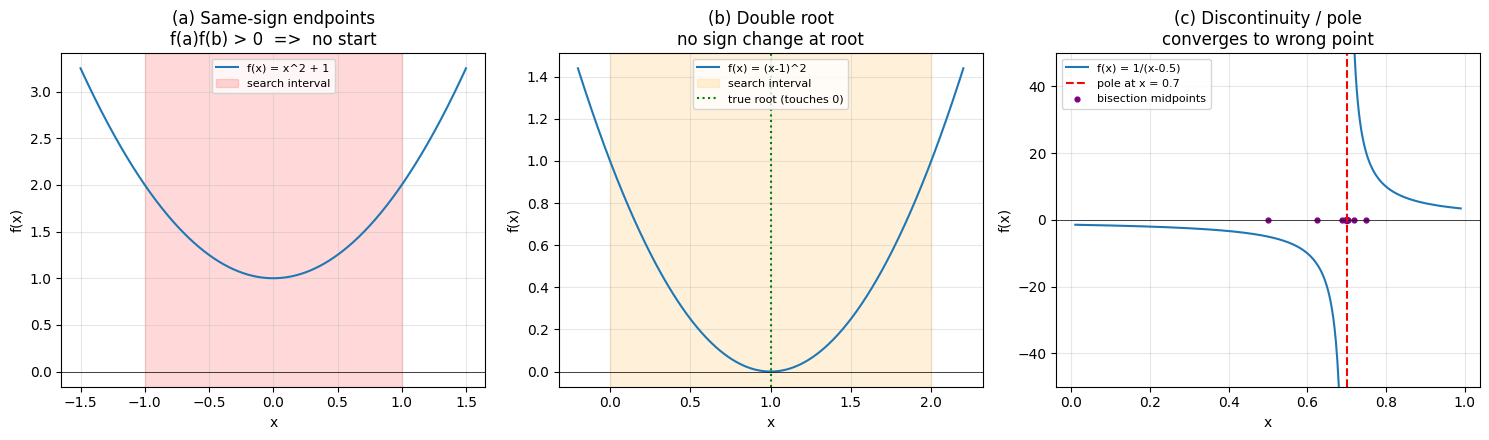

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a)
xa = np.linspace(-1.5, 1.5, 400)
axes[0].plot(xa, fa(xa), label="f(x) = x^2 + 1")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].axvspan(-1, 1, alpha=0.15, color="red", label="search interval")
axes[0].set_title("(a) Same-sign endpoints\nf(a)f(b) > 0  =>  no start")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

# (b)
xb = np.linspace(-0.2, 2.2, 400)
axes[1].plot(xb, fb_(xb), label="f(x) = (x-1)^2")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].axvspan(0, 2, alpha=0.15, color="orange", label="search interval")
axes[1].axvline(1, color="green", ls=":", label="true root (touches 0)")
axes[1].set_title("(b) Double root\nno sign change at root")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

# (c)
xc = np.linspace(0.01, 0.69, 200)
xc2 = np.linspace(0.71, 0.99, 200)
axes[2].plot(xc, fc_(xc), color="C0", label="f(x) = 1/(x-0.5)")
axes[2].plot(xc2, fc_(xc2), color="C0")
axes[2].axhline(0, color="black", lw=0.5)
axes[2].axvline(0.7, color="red", ls="--", label="pole at x = 0.7")
n_axis = np.arange(1, len(hc) + 1)
cs = np.array([row[3] for row in hc])
axes[2].scatter(cs[:15], np.zeros_like(cs[:15]), s=12, color="purple",
                label="bisection midpoints")
axes[2].set_ylim(-50, 50)
axes[2].set_title("(c) Discontinuity / pole\nconverges to wrong point")
axes[2].set_xlabel("x"); axes[2].set_ylabel("f(x)")
axes[2].grid(True, alpha=0.3); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


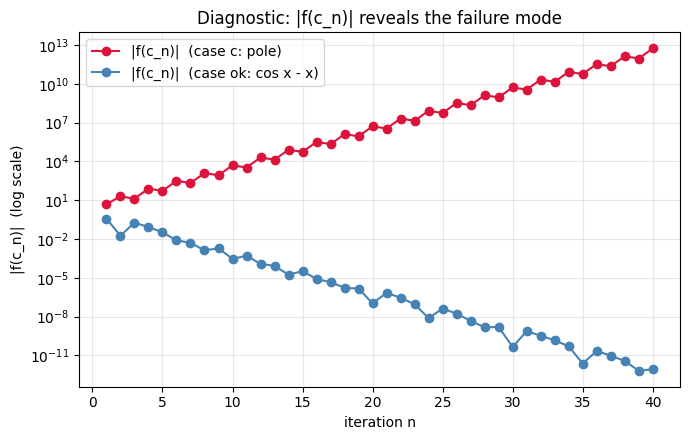

In [4]:
# Diagnostic: |f(c_n)| should -> 0 in a valid run; it diverges in (c).
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(df_c["n"].values, df_c["|f(c_n)|"].values, "o-", color="crimson",
            label="|f(c_n)|  (case c: pole)")
# compare with a normal run
ok_hist = []
fn_ok = lambda x: np.cos(x) - x
_, ok_h, _ = bisect_raw(fn_ok, 0.0, 1.0, Nmax=50)
ax.semilogy(np.arange(1, len(ok_h) + 1),
            np.abs([row[4] for row in ok_h]),
            "o-", color="steelblue", label="|f(c_n)|  (case ok: cos x - x)")
ax.set_xlabel("iteration n")
ax.set_ylabel("|f(c_n)|  (log scale)")
ax.set_title("Diagnostic: |f(c_n)| reveals the failure mode")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

- **(a)** $f(x) = x^2 + 1$ on $[-1, 1]$ : 양 끝 모두 $+$ 이므로 알고리즘이 *시작 자체* 를 못 함.
  이 경우 `ValueError` 같은 명시적 실패가 *원하는* 동작 — 사용자에게 가정 위반을 알려야 한다.
- **(b)** $f(x) = (x - 1)^2$ on $[0, 2]$ : 양 끝 모두 $+$ 이라 (a) 처럼 시작 못 함. 짝수 중복도 근은
  *어떤* 구간을 잡아도 부호 변화가 없어, **이분법으로는 원리상 못 푼다**. Newton 같은
  *값/도함수 기반* 방법으로 가야 하며, 그것도 다중근에서는 수렴 차수가 떨어진다 (§3.2 에서 다룸).
- **(c)** $f(x) = 1/(x-0.7)$ on $[0, 1]$ : $f(0) = -2, f(1) = +2$ 이라 부호 변화는 *있다*.
  이분법은 $c_n \to 0.7$ 로 *수렴* 하지만, 정작 그 점은 **근이 아니라 극(pole)** 이다.
  $|f(c_n)|$ 이 발산하는 것이 *치명적 신호*. 따라서 수렴 후에도 반드시 $|f(c_n)|$ 을 확인해야 함.

### 견고한 bisection 체크리스트
1. **사전** : `f(a) * f(b) < 0` 검사. 위반 시 즉시 실패 보고.
2. **사후** : 수렴 후 $|f(c_n)|$ 이 충분히 작은지 확인. 크다면 *불연속/극* 의심.
3. **다중근** : bisection 으로 다중근은 풀 수 없다. Newton (적절히 수정) 또는 minimization 으로.
4. **연속성 가정** : 사용자가 입력 함수의 연속성을 보장해야 한다 — 알고리즘이 검증할 수 없다.

### 결론
> **이분법은 *부호변화* 를 *영점* 으로 잘못 해석할 수 있다.**
> 이는 알고리즘의 결함이 아니라 그 *가정(연속성)* 의 결과이며,
> 견고한 root finder 는 항상 *수렴 후 함숫값* 을 함께 검사한다.

### 다음 단원 연결
- **§3.2 Newton's Method (Day 12)**: 이번에 발견한 *다중근* 과 *발산* 케이스가 Newton 에서도
  유사하게 — 그러나 다른 모양으로 — 나타난다. Newton 은 *도함수* 가정을 추가로 요구하므로
  실패 모드는 더 다양하지만 정상 작동 시 *이차 수렴* 의 이점이 압도적.
- **§3.4 (이후)**: 견고성을 위해 bisection 과 Newton/secant 를 *합친* hybrid method
  (Dekker–Brent) 의 동기와 구조.
